### Analyzing all the data I got from final-file.ipynb which was converted to a csv. It contains the logistic model for 2022 and 2023

In [18]:
import pandas as pd
from collections import defaultdict

In [23]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# show all columns
pd.set_option("display.max_columns", None)

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [25]:
%%R

require('tidyverse')
require('DescTools')
require('ggplot2')
require('dplyr')


In [27]:
df = pd.read_csv("mens-analysis1-df.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8771 entries, 0 to 8770
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 8771 non-null   int64  
 1   tournament           8771 non-null   object 
 2   surface              8771 non-null   object 
 3   five_set             8771 non-null   bool   
 4   player_A_name        8771 non-null   object 
 5   player_B_name        8771 non-null   object 
 6   player_A_elo_before  8771 non-null   float64
 7   player_B_elo_before  8771 non-null   float64
 8   player_A_win         8771 non-null   int64  
 9   elo_difference       8771 non-null   float64
 10  surface_cluster_A    8771 non-null   int64  
 11  surface_cluster_B    8771 non-null   int64  
 12  predict_proba_R      8771 non-null   float64
 13  predict_R            8771 non-null   int64  
dtypes: bool(1), float64(4), int64(5), object(4)
memory usage: 899.5+ KB


## See all rows where prediction went wrong

In [30]:
df_filtered = df[df['player_A_win'] != df['predict_R']].sort_values(by='predict_proba_R', ascending=False)
df_filtered

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,surface_cluster_A,surface_cluster_B,predict_proba_R,predict_R
8704,20240115,Australian Open,Hard,True,Grigor Dimitrov,Nuno Borges,1845.968429,1468.653977,0,377.314453,1,2,0.957648,1
8701,20230529,Roland Garros,Clay,True,Jannik Sinner,Daniel Altmaier,1778.715529,1404.601488,0,374.114041,1,1,0.939107,1
8197,20220829,Us Open,Hard,True,Taylor Fritz,Brandon Holt,1685.448494,1484.181722,0,201.266772,1,0,0.895420,1
8237,20240701,Wimbledon,Grass,True,Karen Khachanov,Quentin Halys,1688.869629,1480.472725,0,208.396904,1,2,0.894523,1
8356,20240115,Australian Open,Hard,True,Holger Rune,Arthur Cazaux,1729.387956,1499.967405,0,229.420551,1,3,0.886852,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,20220516,Geneva,Clay,False,Benoit Paire,Emil Ruusuvuori,1373.148471,1545.675008,1,-172.526538,0,1,0.039951,0
710,20230717,Gstaad,Clay,False,Zizou Bergs,Laslo Djere,1382.882479,1561.210227,1,-178.327748,0,1,0.038996,0
480,20230612,Stuttgart,Grass,False,Yibing Wu,Nick Kyrgios,1539.061196,1749.577844,1,-210.516649,3,1,0.035081,0
467,20240722,Umag,Clay,False,Chun Hsin Tseng,Fabio Fognini,1368.802854,1581.730241,1,-212.927387,0,1,0.033739,0


### Most surprising upsets

In [43]:
# 1. Filter for high-confidence upsets
high_conf_upsets = df[
    (df['predict_R'] == 1) & 
    (df['predict_proba_R'] > 0.75) & 
    (df['player_A_win'] == 0)
]

# 2. Count which Player B caused the most high-confidence upsets
high_conf_upsets.sort_values(by='predict_R', ascending=False)

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,surface_cluster_A,surface_cluster_B,predict_proba_R,predict_R
4875,20220131,Pune,Hard,False,Cem Ilkel,Vit Kopriva,1500.000000,1485.654322,0,14.345678,3,0,0.753614,1
8321,20240422,Madrid Masters,Clay,False,Frances Tiafoe,Pedro Cachin,1610.776160,1387.977605,0,222.798555,1,2,0.763094,1
8464,20240715,Hamburg,Clay,False,Alexander Zverev,Arthur Fils,1862.807681,1608.939127,0,253.868554,1,1,0.753376,1
8452,20240422,Madrid Masters,Clay,False,Grigor Dimitrov,Jakub Mensik,1857.609909,1607.808865,0,249.801045,1,1,0.750079,1
8443,20240506,Rome Masters,Clay,False,Tallon Griekspoor,Francesco Passaro,1661.759529,1414.063639,0,247.695890,1,2,0.782083,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7945,20240115,Australian Open,Hard,True,Alejandro Davidovich Fokina,Nuno Borges,1659.926297,1492.737026,0,167.189271,1,2,0.830589,1
7841,20230703,Wimbledon,Grass,True,Taylor Fritz,Mikael Ymer,1686.303948,1529.660280,0,156.643668,1,1,0.798462,1
7809,20230529,Roland Garros,Clay,True,Holger Rune,Casper Ruud,1807.325389,1654.423795,0,152.901595,1,1,0.755194,1
7790,20240819,Winston-Salem,Hard,False,Tomas Martin Etcheverry,Zizou Bergs,1589.670901,1438.246018,0,151.424882,1,0,0.792616,1


### Who performed better during a long match

In [15]:
long_matches_overall = df[(df['five_set'] == True) & (df['player_A_win'] == 1)]
long_matches_overall['player_A_name'].value_counts().head(50)

player_A_name
Novak Djokovic                 32
Carlos Alcaraz                 27
Jannik Sinner                  24
Alexander Zverev               20
Taylor Fritz                   18
Andrey Rublev                  18
Casper Ruud                    16
Daniil Medvedev                16
Grigor Dimitrov                14
Stefanos Tsitsipas             14
Karen Khachanov                13
Tommy Paul                     13
Frances Tiafoe                 12
Cameron Norrie                 12
Denis Shapovalov               12
Hubert Hurkacz                 11
Holger Rune                    11
Alex De Minaur                 10
Lorenzo Musetti                10
Tomas Martin Etcheverry         9
Botic Van De Zandschulp         9
Ben Shelton                     9
Corentin Moutet                 8
Alejandro Davidovich Fokina     8
Alexei Popyrin                  8
Daniel Evans                    7
Miomir Kecmanovic               7
Rafael Nadal                    7
Francisco Cerundolo             6


In [16]:
%%R -i long_matches_overall

# Step 1: Filter for 5-set wins as Player A and count them
long_match_wins <- long_matches_overall %>%
  filter(five_set == TRUE, player_A_win == 1) %>%
  count(player_A_name, sort = TRUE) %>%
  top_n(50, n)  # get top 50 players

# Optional: rename for clarity
colnames(long_match_wins) <- c("player", "wins")


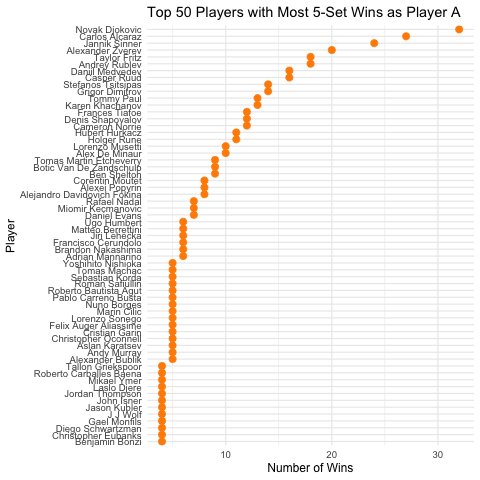

In [17]:
%%R
ggplot(long_match_wins, aes(x = reorder(player, wins), y = wins)) +
  geom_point(size = 3, color = "darkorange") +
  coord_flip() +
  labs(
    title = "Top 50 Players with Most 5-Set Wins as Player A",
    x = "Player",
    y = "Number of Wins"
  ) +
  theme_minimal(base_size = 12)


### ^^ They're all top players!

### Analyzing 2024 data

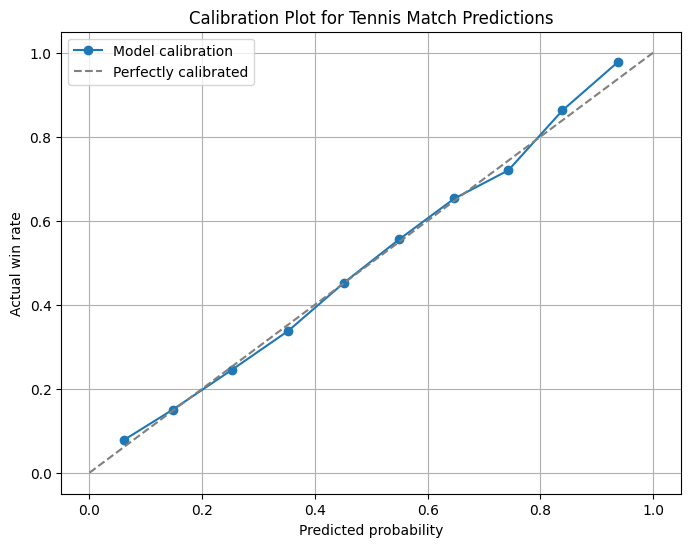

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Assuming your DataFrame is called df
# If not, replace 'df' with your actual DataFrame variable

# 1. Get predicted probabilities and actual outcomes
y_true = df['player_A_win']
y_prob = df['predict_proba_R']

# 2. Compute calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')

# 3. Plot calibration curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('Actual win rate')
plt.title('Calibration Plot for Tennis Match Predictions')
plt.legend()
plt.grid(True)
plt.show()